<a href="https://colab.research.google.com/github/annetken/Monte-Carlo-Error-Reduction/blob/main/Monte_Carlo_Error_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Exercise 2 python solution
import numpy as np
from scipy.stats import norm


def geometric_asian_call_price(
    S0: float,
    K: float,
    r: float,
    sigma: float,
    T: float,
    m: int,
) -> float:
    """
    Closed-form price of a discretely monitored geometric Asian call.

    Monitoring dates are t_j = jT/m for j = 1,...,m.
    """
    average_time = T * (m + 1) / (2 * m)

    log_variance = (
        sigma**2
        * T
        * (m + 1)
        * (2 * m + 1)
        / (6 * m**2)
    )

    log_mean = (
        np.log(S0)
        + (r - 0.5 * sigma**2) * average_time
    )

    sqrt_variance = np.sqrt(log_variance)

    d1 = (
        log_mean
        - np.log(K)
        + log_variance
    ) / sqrt_variance

    d2 = d1 - sqrt_variance

    price = np.exp(-r * T) * (
        np.exp(log_mean + 0.5 * log_variance) * norm.cdf(d1)
        - K * norm.cdf(d2)
    )

    return float(price)


def asian_control_variate_mc(
    S0: float = 100.0,
    K: float = 100.0,
    r: float = 0.05,
    sigma: float = 0.30,
    T: float = 1.0,
    m: int = 12,
    M: int = 100_000,
    seed: int = 42,
) -> dict:
    """
    Prices an arithmetic Asian call using:
    1. Plain Monte Carlo
    2. A geometric Asian control variate
    """
    if M <= 1:
        raise ValueError("M must be greater than 1.")
    if m <= 0:
        raise ValueError("m must be positive.")
    if sigma < 0 or T <= 0:
        raise ValueError("sigma must be non-negative and T positive.")

    rng = np.random.default_rng(seed)

    dt = T / m
    discount = np.exp(-r * T)

    # Generate all Brownian shocks.
    Z = rng.standard_normal((M, m))

    # Exact log-GBM increments.
    log_increments = (
        (r - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * Z
    )

    # Generate log prices at the 12 monitoring dates.
    log_paths = (
        np.log(S0)
        + np.cumsum(log_increments, axis=1)
    )

    paths = np.exp(log_paths)

    # Arithmetic and geometric averages.
    arithmetic_average = np.mean(paths, axis=1)
    geometric_average = np.exp(np.mean(log_paths, axis=1))

    # Discounted payoffs.
    X = discount * np.maximum(arithmetic_average - K, 0.0)
    Y = discount * np.maximum(geometric_average - K, 0.0)

    # Plain MC.
    plain_estimate = np.mean(X)
    plain_variance = np.var(X, ddof=1)
    plain_se = np.sqrt(plain_variance / M)

    # Known geometric Asian option price.
    expected_Y = geometric_asian_call_price(
        S0, K, r, sigma, T, m
    )

    # Estimated optimal control coefficient.
    covariance_XY = np.cov(X, Y, ddof=1)[0, 1]
    variance_Y = np.var(Y, ddof=1)

    if variance_Y <= 0:
        raise ValueError("Control variate has zero variance.")

    theta_hat = covariance_XY / variance_Y

    # Controlled observations.
    X_controlled = X - theta_hat * (Y - expected_Y)

    controlled_estimate = np.mean(X_controlled)
    controlled_variance = np.var(X_controlled, ddof=1)
    controlled_se = np.sqrt(controlled_variance / M)

    rho_hat = np.corrcoef(X, Y)[0, 1]

    variance_reduction_factor = (
        plain_variance / controlled_variance
    )

    effective_sample_size = (
        M * variance_reduction_factor
    )

    return {
        "plain_estimate": plain_estimate,
        "plain_se": plain_se,
        "geometric_asian_price": expected_Y,
        "controlled_estimate": controlled_estimate,
        "controlled_se": controlled_se,
        "theta_hat": theta_hat,
        "rho_hat": rho_hat,
        "variance_reduction_factor": variance_reduction_factor,
        "effective_sample_size": effective_sample_size,
    }


results = asian_control_variate_mc()

for name, value in results.items():
    print(f"{name}: {value:.6f}")

plain_estimate: 8.480247
plain_se: 0.040693
geometric_asian_price: 8.024703
controlled_estimate: 8.476104
controlled_se: 0.001699
theta_hat: 1.048711
rho_hat: 0.999128
variance_reduction_factor: 573.897828
effective_sample_size: 57389782.757035


In [ ]:
# Question 3 part 2
import numpy as np

S0 = 100
sigma = 0.2
r = 0.05
T = 1
M = 100_000

strikes = [100, 120, 140, 160, 180, 200]

rng = np.random.default_rng(42)

# Generate the random shocks
Z = rng.standard_normal(M)

# Simulate terminal stock prices
ST = S0 * np.exp(
    (r - 0.5 * sigma**2) * T
    + sigma * np.sqrt(T) * Z
)

for K in strikes:
    discounted_payoffs = (
        np.exp(-r * T)
        * np.maximum(ST - K, 0)
    )

    price = np.mean(discounted_payoffs)

    standard_error = (
        np.std(discounted_payoffs, ddof=1)
        / np.sqrt(M)
    )

    print(
        f"K = {K}, "
        f"Plain MC price = {price:.8f}, "
        f"SE = {standard_error:.8f}"
    )

K = 100, Plain MC price = 10.42054119, SE = 0.04676990
K = 120, Plain MC price = 3.26686289, SE = 0.02767992
K = 140, Plain MC price = 0.80207477, SE = 0.01369874
K = 160, Plain MC price = 0.16574655, SE = 0.00619040
K = 180, Plain MC price = 0.03095373, SE = 0.00282764
K = 200, Plain MC price = 0.00692549, SE = 0.00144977



EXERCISE 3 RESULTS

      Strike    BS Price  Plain MC Price  Plain MC SE  Plain Positive Payoff Ratio  Theta Star    IS Price      IS SE  IS Positive Payoff Ratio  Variance Reduction Factor
100.00000000 10.45058357     10.42054119   0.04676990                   0.55750000 -0.15000000 10.53045215 0.05675529                0.50121000                 0.67907888
120.00000000  3.24747742      3.26686289   0.02767992                   0.22274000  0.76160778  3.24581269 0.01201678                0.50044000                 5.30582631
140.00000000  0.78496530      0.80207477   0.01369874                   0.06266000  1.53236118  0.78506511 0.00276545                0.50012000                24.53753308
160.00000000  0.15895425      0.16574655   0.00619040                   0.01425000  2.20001815  0.15848206 0.00058693                0.49837000               111.24165386
180.00000000  0.02864286      0.03095373   0.00282764                   0.00265000  2.78893332  0.02859194 0.00011325       

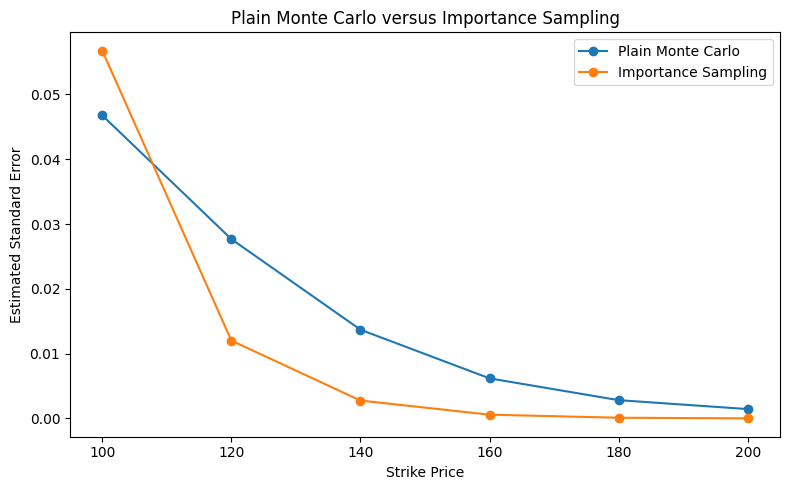

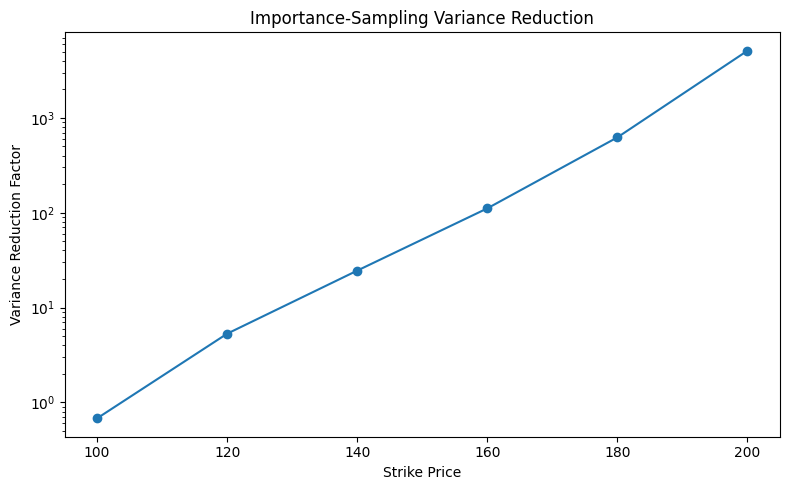

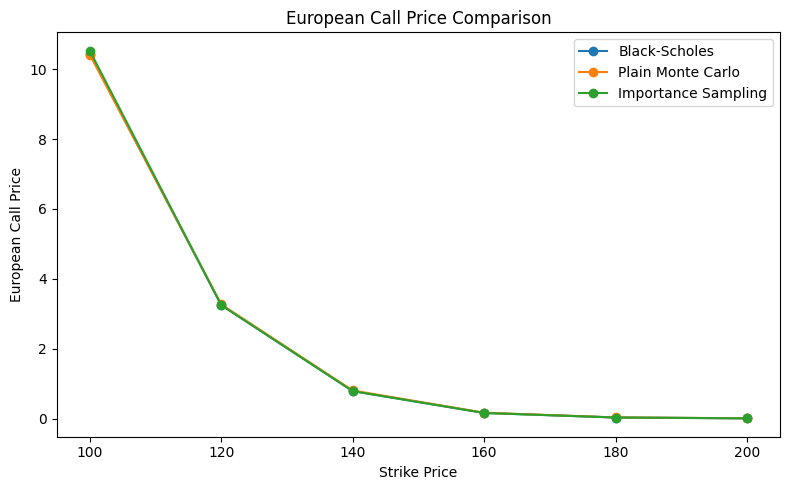


Exercise 3 files created successfully.
ZIP file: /content/Exercise_3_Importance_Sampling_Output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#exercise 3 IMPORTANCE SAMPLING FOR OTM EUROPEAN CALLS


import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm


# ============================================================
# 1. INPUT PARAMETERS


S0 = 100.0
sigma = 0.20
r = 0.05
T = 1.0
M = 100_000

strikes = np.array(
    [100, 120, 140, 160, 180, 200],
    dtype=float,
)

SEED = 42


# Create one output folder
OUTPUT_FOLDER = Path(
    "Exercise_3_Importance_Sampling_Output"
)

OUTPUT_FOLDER.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. PART 1: BLACK-SCHOLES CALL PRICE


def black_scholes_call(
    S0: float,
    K: float,
    r: float,
    sigma: float,
    T: float,
) -> float:
    """
    Black-Scholes price of a European call.
    """

    d1 = (
        np.log(S0 / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    call_price = (
        S0 * norm.cdf(d1)
        - K
        * np.exp(-r * T)
        * norm.cdf(d2)
    )

    return float(call_price)


# ============================================================
# 3. PART 2: PLAIN MONTE CARLO


def plain_mc_call(
    S0: float,
    K: float,
    r: float,
    sigma: float,
    T: float,
    Z: np.ndarray,
) -> dict:
    """
    Price a European call using plain Monte Carlo.
    """

    terminal_prices = S0 * np.exp(
        (r - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )

    discounted_payoffs = (
        np.exp(-r * T)
        * np.maximum(
            terminal_prices - K,
            0.0,
        )
    )

    estimate = np.mean(
        discounted_payoffs
    )

    standard_error = (
        np.std(
            discounted_payoffs,
            ddof=1,
        )
        / np.sqrt(len(Z))
    )

    positive_payoff_ratio = np.mean(
        terminal_prices > K
    )

    return {
        "estimate": float(estimate),
        "se": float(standard_error),
        "positive_payoff_ratio":
            float(positive_payoff_ratio),
    }


# ============================================================
# 4. PART 3: OPTIMAL DRIFT SHIFT


def optimal_drift_shift(
    S0: float,
    K: float,
    r: float,
    sigma: float,
    T: float,
) -> float:
    """
    Importance-sampling drift shift supplied in the exercise.
    """

    theta_star = (
        np.log(K / S0)
        - (r - 0.5 * sigma**2) * T
    ) / (sigma * T)

    return float(theta_star)


# ============================================================
# 5. PART 4: IMPORTANCE SAMPLING


def importance_sampling_call(
    S0: float,
    K: float,
    r: float,
    sigma: float,
    T: float,
    Z: np.ndarray,
) -> dict:
    """
    Price a European call using drift-shift
    importance sampling.
    """

    theta_star = optimal_drift_shift(
        S0=S0,
        K=K,
        r=r,
        sigma=sigma,
        T=T,
    )

    shifted_brownian_terminal = (
        np.sqrt(T) * Z
        + theta_star * T
    )

    shifted_terminal_prices = S0 * np.exp(
        (r - 0.5 * sigma**2) * T
        + sigma
        * shifted_brownian_terminal
    )

    likelihood_ratio = np.exp(
        -theta_star * np.sqrt(T) * Z
        - 0.5 * theta_star**2 * T
    )

    weighted_discounted_payoffs = (
        np.exp(-r * T)
        * np.maximum(
            shifted_terminal_prices - K,
            0.0,
        )
        * likelihood_ratio
    )

    estimate = np.mean(
        weighted_discounted_payoffs
    )

    standard_error = (
        np.std(
            weighted_discounted_payoffs,
            ddof=1,
        )
        / np.sqrt(len(Z))
    )

    positive_payoff_ratio = np.mean(
        shifted_terminal_prices > K
    )

    return {
        "theta_star": float(theta_star),
        "estimate": float(estimate),
        "se": float(standard_error),
        "positive_payoff_ratio":
            float(positive_payoff_ratio),
    }


# ============================================================
# 6. RUN THE SIMULATIONS


rng = np.random.default_rng(SEED)

# Use one common sample for plain MC
Z_plain = rng.standard_normal(M)

results = []

for K in strikes:

    # Part 1: analytical price
    bs_price = black_scholes_call(
        S0=S0,
        K=K,
        r=r,
        sigma=sigma,
        T=T,
    )

    # Part 2: plain MC
    plain_results = plain_mc_call(
        S0=S0,
        K=K,
        r=r,
        sigma=sigma,
        T=T,
        Z=Z_plain,
    )

    # New random sample for IS
    Z_is = rng.standard_normal(M)

    # Parts 3 and 4: importance sampling
    is_results = importance_sampling_call(
        S0=S0,
        K=K,
        r=r,
        sigma=sigma,
        T=T,
        Z=Z_is,
    )

    # Part 5: variance reduction factor
    variance_reduction_factor = (
        plain_results["se"]
        / is_results["se"]
    ) ** 2

    results.append(
        {
            "Strike": K,
            "BS Price": bs_price,
            "Plain MC Price":
                plain_results["estimate"],
            "Plain MC SE":
                plain_results["se"],
            "Plain Positive Payoff Ratio":
                plain_results[
                    "positive_payoff_ratio"
                ],
            "Theta Star":
                is_results["theta_star"],
            "IS Price":
                is_results["estimate"],
            "IS SE":
                is_results["se"],
            "IS Positive Payoff Ratio":
                is_results[
                    "positive_payoff_ratio"
                ],
            "Variance Reduction Factor":
                variance_reduction_factor,
        }
    )


results_table = pd.DataFrame(results)


# ============================================================
# 7. DISPLAY RESULTS


print("\nEXERCISE 3 RESULTS\n")

print(
    results_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.8f}",
    )
)


# ============================================================
# 8. SAVE THE RESULTS TABLES


results_table.to_csv(
    OUTPUT_FOLDER / "exercise3_results.csv",
    index=False,
)

results_table.to_excel(
    OUTPUT_FOLDER / "exercise3_results.xlsx",
    index=False,
)

report_columns = [
    "Strike",
    "BS Price",
    "Plain MC Price",
    "Plain MC SE",
    "Theta Star",
    "IS Price",
    "IS SE",
    "Variance Reduction Factor",
]

latex_table = results_table[
    report_columns
].to_latex(
    index=False,
    float_format="%.6f",
    caption=(
        "Comparison of Black--Scholes, plain Monte Carlo "
        "and importance-sampling estimates."
    ),
    label="tab:exercise3_results",
)

with open(
    OUTPUT_FOLDER / "exercise3_results.tex",
    "w",
    encoding="utf-8",
) as file:
    file.write(latex_table)


# ============================================================
# 9. IDENTIFY WHERE IS IS MOST BENEFICIAL


best_index = results_table[
    "Variance Reduction Factor"
].idxmax()

best_result = results_table.loc[
    best_index
]

best_strike = best_result["Strike"]
best_vrf = best_result[
    "Variance Reduction Factor"
]


# ============================================================
# 10. SAVE REPORT SUMMARY


summary_text = f"""
EXERCISE 3: IMPORTANCE SAMPLING FOR OTM OPTIONS

Parameters
----------
S0 = {S0}
sigma = {sigma}
r = {r}
T = {T}
M = {M}
Random seed = {SEED}

Main result
-----------
The largest estimated variance reduction occurred at:

Strike K = {best_strike:.0f}

Variance reduction factor:
{best_vrf:.4f}

Plain Monte Carlo standard error:
{best_result['Plain MC SE']:.10f}

Importance-sampling standard error:
{best_result['IS SE']:.10f}

Interpretation
--------------
Plain Monte Carlo becomes less efficient as the call option becomes
more deeply out of the money because most simulated payoffs are zero.

Importance sampling shifts the terminal stock-price distribution
towards the strike, causing positive payoffs to occur more frequently.
The likelihood-ratio weight corrects for this change of distribution.

Importance sampling is therefore most beneficial for the highest and
deepest out-of-the-money strikes.
""".strip()

with open(
    OUTPUT_FOLDER / "exercise3_summary.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(summary_text)


# ============================================================
# 11. FIGURE 1: STANDARD ERROR COMPARISON


plt.figure(figsize=(8, 5))

plt.plot(
    results_table["Strike"],
    results_table["Plain MC SE"],
    marker="o",
    label="Plain Monte Carlo",
)

plt.plot(
    results_table["Strike"],
    results_table["IS SE"],
    marker="o",
    label="Importance Sampling",
)

plt.xlabel("Strike Price")
plt.ylabel("Estimated Standard Error")
plt.title(
    "Plain Monte Carlo versus Importance Sampling"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER
    / "standard_error_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 12. FIGURE 2: VARIANCE REDUCTION FACTOR


plt.figure(figsize=(8, 5))

plt.plot(
    results_table["Strike"],
    results_table[
        "Variance Reduction Factor"
    ],
    marker="o",
)

plt.xlabel("Strike Price")
plt.ylabel("Variance Reduction Factor")
plt.title(
    "Importance-Sampling Variance Reduction"
)

plt.yscale("log")
plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER
    / "variance_reduction_factor.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 13. FIGURE 3: OPTION PRICE COMPARISON


plt.figure(figsize=(8, 5))

plt.plot(
    results_table["Strike"],
    results_table["BS Price"],
    marker="o",
    label="Black-Scholes",
)

plt.plot(
    results_table["Strike"],
    results_table["Plain MC Price"],
    marker="o",
    label="Plain Monte Carlo",
)

plt.plot(
    results_table["Strike"],
    results_table["IS Price"],
    marker="o",
    label="Importance Sampling",
)

plt.xlabel("Strike Price")
plt.ylabel("European Call Price")
plt.title("European Call Price Comparison")

plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER
    / "price_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 14. CREATE ZIP FILE


zip_path = shutil.make_archive(
    base_name=(
        "Exercise_3_Importance_Sampling_Output"
    ),
    format="zip",
    root_dir=OUTPUT_FOLDER,
)

print("\nExercise 3 files created successfully.")
print(f"ZIP file: {zip_path}")


# ============================================================
# 15. AUTOMATIC DOWNLOAD IN GOOGLE COLAB


try:
    from google.colab import files

    files.download(zip_path)

except ImportError:
    print(
        "\nAutomatic download only works in Google Colab. "
        "The ZIP file has been saved in the current folder."
    )